# Bike and Car Classification (Model Inference)

Nama : Hafizal Shakur

**Objective:**

Notebook ini dibuat untuk melakukan data inference mengenai Computer Vision menggunakan model Convlutional Neural Network untuk memprediksi kelas `Bike` dan `Car` dari notebook utama `P2G7_hafizal_shakur.ipynb`.

In [ ]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive

In [ ]:
# mengakses google drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# menampikan isi directory
!ls '/content/drive/My Drive/GC7/'

# link model https://drive.google.com/drive/folders/1cD5YXnsDM5h51ZcXKgItThOTkNpLklv8?usp=drive_link

bike_and_car_model1.keras  bike_and_car_model2.keras  model1_checkpoint.keras
bike_and_car_model1.zip    bike_and_car_model2.zip    model2_checkpoint.keras


In [ ]:
# mendefinisikan model
model1 = tf.keras.models.load_model('/content/drive/My Drive/GC7/model1_checkpoint.keras')
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 298, 298, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 149, 149, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 147, 147, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 71, 71, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 35, 35, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling2d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling2D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 329,669 (1.26 MB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 219,780 (858.52 KB)

In [ ]:
# fungsi untuk prediksi gambar
def prediction(file, model):
  img = tf.keras.utils.load_img(file, target_size=(300,300))
  x = tf.keras.utils.img_to_array(img)/255

  plt.imshow(img)

  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  y_pred_proba = model.predict(images)
  y_pred_class = 1 if y_pred_proba[0][0] > 0.5 else 0

  class_name = ['Bike', 'Car']
  y_pred_class_name = class_name[y_pred_class]

  print('Prediction: {} (Confidence: {:.2f})'.format(y_pred_class_name, y_pred_proba[0][0]))

In [ ]:
# download image untuk data inference
! wget 'https://wallpaper.dog/large/20493151.jpg' -O 'bike1_inf.jpg'
! wget 'https://th.bing.com/th/id/OIP.wik1fkGdFM_0oD-WTngC7QHaEK?rs=1&pid=ImgDetMain' -O 'bike2_inf.jpg'
! wget 'https://th.bing.com/th/id/R.d5da786ec4c5d8ab21a6cb682c3d9b79?rik=xAh2AazQCmEagw&riu=http%3a%2f%2fpluspng.com%2fimg-png%2fpng-hd-bike-bajaj-pulsar-rs-200-png-clipart-1072.png&ehk=l80NjpPsIueDCFsYNFIIFHgCpyp2DX0GurAd0fCCqfk%3d&risl=&pid=ImgRaw&r=0' -O 'bike3_inf.jpg'
! wget 'https://th.bing.com/th/id/OIP.dC9dqSZ9raI8Qj91nmRQaQHaEW?rs=1&pid=ImgDetMain' -O 'car1_inf.jpg'
! wget 'https://th.bing.com/th/id/OIP.fja0SCrVxbcvZByDZABO9gHaEK?rs=1&pid=ImgDetMain' -O 'car2_inf.jpg'
! wget 'https://th.bing.com/th/id/OIP.MpAWsdgNakLHN-5amrp4SQHaEK?rs=1&pid=ImgDetMain' -O 'car3_inf.jpg'

--2025-04-07 14:45:10--  https://wallpaper.dog/large/20493151.jpg
Resolving wallpaper.dog (wallpaper.dog)... 104.21.64.1, 104.21.112.1, 104.21.80.1, ...
Connecting to wallpaper.dog (wallpaper.dog)|104.21.64.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186595 (182K) [image/jpeg]
Saving to: ‘bike1_inf.jpg’

bike1_inf.jpg       100%[===================>] 182.22K  --.-KB/s    in 0.03s   

2025-04-07 14:45:10 (5.38 MB/s) - ‘bike1_inf.jpg’ saved [186595/186595]

--2025-04-07 14:45:10--  https://th.bing.com/th/id/OIP.wik1fkGdFM_0oD-WTngC7QHaEK?rs=1&pid=ImgDetMain
Resolving th.bing.com (th.bing.com)... 23.33.29.205, 23.33.29.210, 23.33.29.204, ...
Connecting to th.bing.com (th.bing.com)|23.33.29.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25480 (25K) [image/jpeg]
Saving to: ‘bike2_inf.jpg’

bike2_inf.jpg       100%[===================>]  24.88K  --.-KB/s    in 0.01s   

2025-04-07 14:45:10 (2.41 MB/s) - ‘bike2_inf.jpg’ saved [254

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Prediction: Car (Confidence: 0.66)


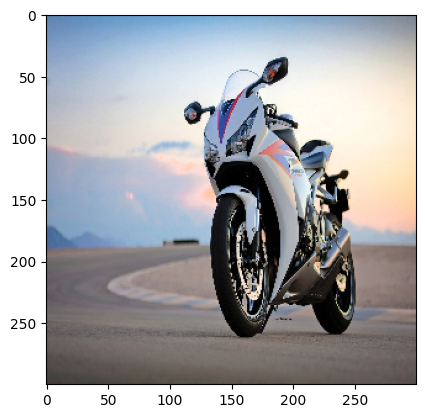

In [ ]:
# prediksi 1
prediction('bike1_inf.jpg', model1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Prediction: Bike (Confidence: 0.03)


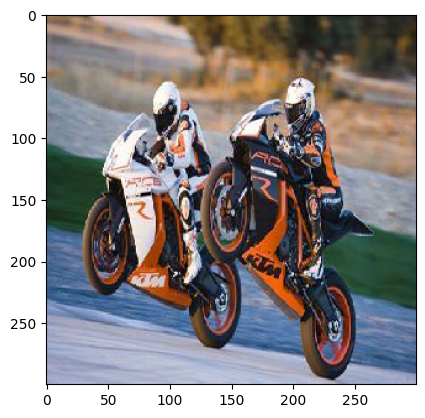

In [ ]:
# prediksi 2
prediction('bike2_inf.jpg', model1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Prediction: Bike (Confidence: 0.04)


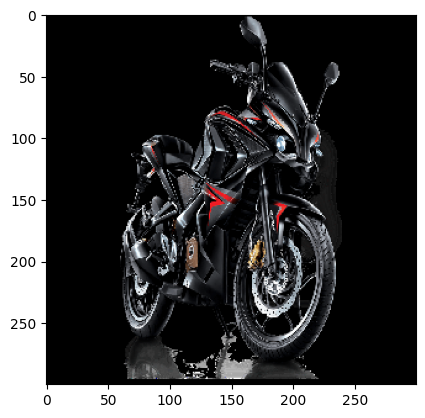

In [ ]:
# prediksi 3
prediction('bike3_inf.jpg', model1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Prediction: Car (Confidence: 0.99)


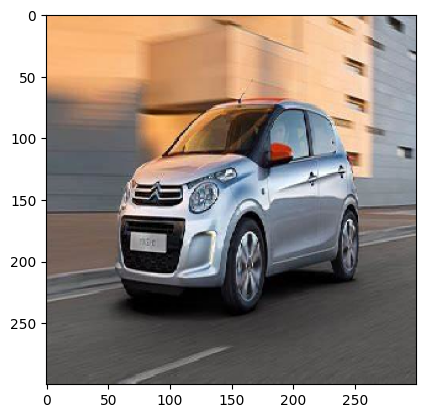

In [ ]:
# prediksi 4
prediction('car1_inf.jpg', model1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Prediction: Car (Confidence: 0.93)


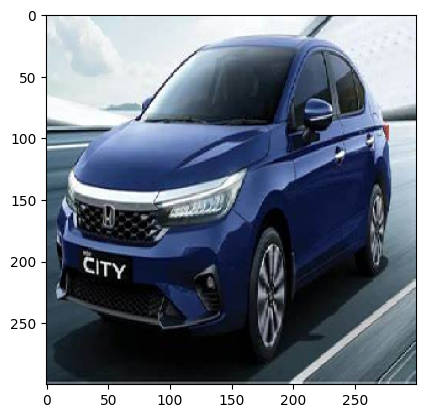

In [ ]:
# prediksi 5
prediction('car2_inf.jpg', model1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
Prediction: Car (Confidence: 0.57)


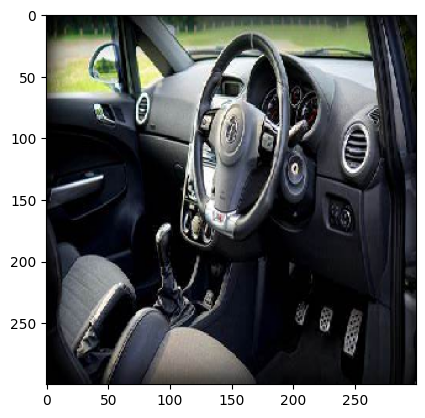

In [ ]:
# prediksi 6
prediction('car3_inf.jpg', model1)

Dari 3 gambar motor dan 3 gambar mobil yang diuji, model mampu memprediksi dengan baik 5 dari total keseluruhan gambar, dimana terdapat kesalahan dalam memprediksi kelas pada salah satu gambar motor.

Kesimpulan selanjutnya akan dilakukan pada notebook` model_building.ipynb`.